In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv('/content/train.csv',usecols=['Survived','Age','Fare'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(714, 3)

In [ ]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state =42)

In [ ]:
x_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [ ]:
clf = DecisionTreeClassifier()
clf.fit(x_train,y_train)

y_pred = clf.predict(x_test)

accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.6153846153846154


In [ ]:
np.mean(cross_val_score(clf,x,y,cv=10,scoring='accuracy'))

np.float64(0.6317292644757433)

In [ ]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [ ]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])

])

In [ ]:
x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

In [ ]:
trf.named_transformers_['second'].n_bins_

array([15])

In [ ]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [ ]:
output = pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_trf[:,0],
    'fare':x_train['Fare'],
    'fare_trf':x_train_trf[:,1],

})

In [ ]:
output['age_labels'] = pd.cut(x = x_train['Age'],bins = trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x = x_train['Fare'],bins = trf.named_transformers_['first'].bin_edges_[0].tolist())

In [ ]:
output.head()

,age,age_trf,fare,fare_trf,age_labels,fare_labels
328,31.0,8.0,20.5250,8.0,"(30.0, 32.0]","(19.0, 21.0]"
73,26.0,6.0,14.4542,7.0,"(25.0, 28.0]","(6.0, 16.0]"
253,30.0,8.0,16.1000,7.0,"(28.0, 30.0]","(16.0, 19.0]"
719,33.0,9.0,7.7750,2.0,"(32.0, 35.0]","(6.0, 16.0]"
666,25.0,6.0,13.0000,6.0,"(23.0, 25.0]","(6.0, 16.0]"


In [ ]:
clf = DecisionTreeClassifier()

clf.fit(x_train_trf,y_train)

y_pred = clf.predict(x_test_trf)



In [ ]:
accuracy_score(y_test,y_pred)

0.6363636363636364

In [ ]:
X_trf = trf.fit_transform(x)
np.mean(cross_val_score(clf,x,y,cv=10,scoring='accuracy'))

np.float64(0.6303208137715179)

In [ ]:
def binning(bins,strategy):
  kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
  kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

  trf = ColumnTransformer([
      ('first',kbin_age,[0]),
      ('second',kbin_fare,[1])
  ])
  clf = DecisionTreeClassifier()
  x_trf = trf.fit_transform(x)
  print(np.mean(cross_val_score(clf,x,y,cv=10,scoring='accuracy')))

  mt.figure(figsize = (14,4))
  mt.subplot(121)
  mt.hist(x['Age'])
  mt.title('Before Age Binning')

  mt.subplot(122)
  mt.hist(x_trf[:,0],bins = bins,color='red')
  mt.title('After Age Binning')

  mt.show()


  mt.figure(figsize = (14,4))
  mt.subplot(121)
  mt.hist(x['Fare'])
  mt.title('Before Fare Binning')

  mt.subplot(122)
  mt.hist(x_trf[:,1],bins = bins,color = 'red')
  mt.title('After Fare Binning')

  mt.show()

0.6289123630672926


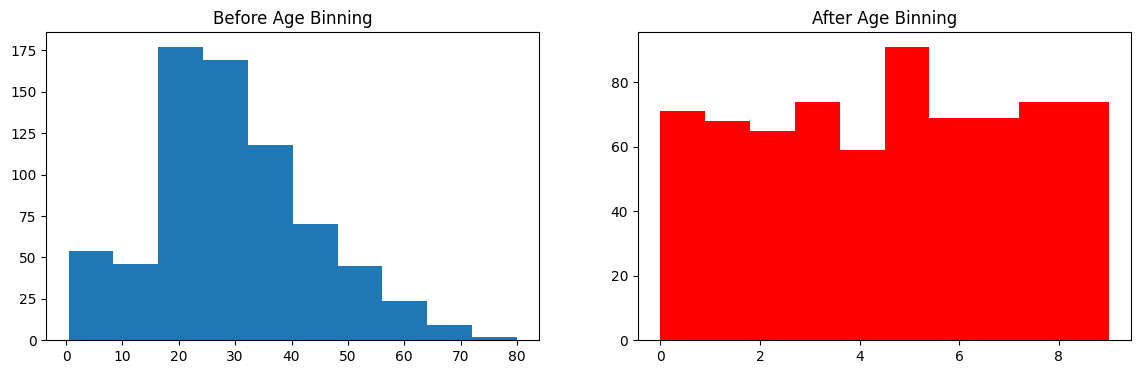

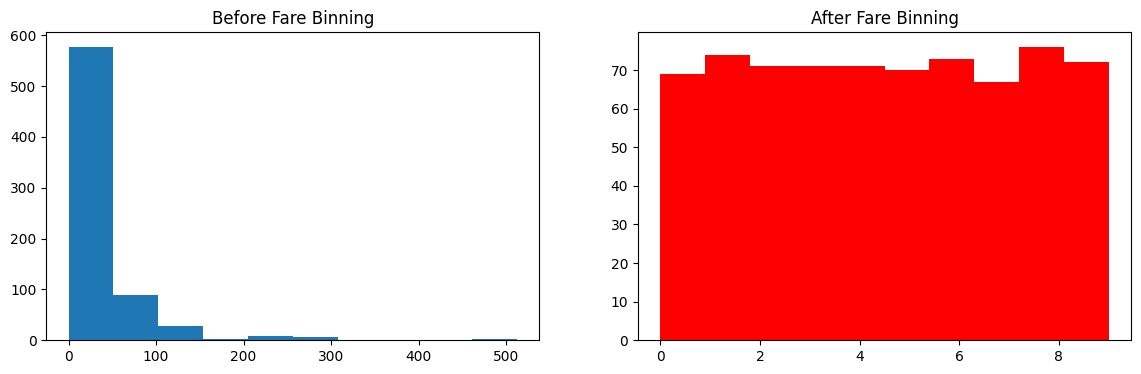

In [ ]:
binning(10,'quantile')